# Part 1: Generating Data

In [1]:
import os
import shutil
import random
import string
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import cv2
import glob
from skimage.metrics import structural_similarity as ssim

In [2]:
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, 'data', 'captcha')
MAPSET_DIR = os.path.join(BASE_DIR, 'data', 'Mapset')
CAPTCHA_LABELS_FILE = os.path.join(BASE_DIR, 'data', 'captcha_labels.csv')
CSV_RESULTS_PATH = os.path.join(DATA_DIR, 'results.csv')
GENERATED_CAPTCHAS_DIR = os.path.join(DATA_DIR, 'generated_captchas')
NOISY_CAPTCHAS_DIR = os.path.join(DATA_DIR, 'noisy_captchas')
FILTERED_CAPTCHAS_DIR = os.path.join(DATA_DIR, 'filtered_captchas')
DENOISED_CAPTCHAS_DIR = os.path.join(DATA_DIR, 'denoised_captchas')
SHARPENED_CAPTCHAS_DIR = os.path.join(DATA_DIR, 'sharpened_captchas')
BINARIZED_CAPTCHAS_DIR = os.path.join(DATA_DIR, 'binarized_captchas')
SEGMENTED_CHARS_DIR = os.path.join(DATA_DIR, "segmented_chars")


if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
os.makedirs(GENERATED_CAPTCHAS_DIR, exist_ok=True)
os.makedirs(NOISY_CAPTCHAS_DIR, exist_ok=True)
os.makedirs(FILTERED_CAPTCHAS_DIR, exist_ok=True)
os.makedirs(DENOISED_CAPTCHAS_DIR, exist_ok=True)
os.makedirs(SHARPENED_CAPTCHAS_DIR, exist_ok=True)
os.makedirs(BINARIZED_CAPTCHAS_DIR, exist_ok=True)
os.makedirs(SEGMENTED_CHARS_DIR, exist_ok=True)

print(f"Data: {DATA_DIR}")
print(f"Mapset: {MAPSET_DIR}")

np.random.seed(94)
random.seed(94)

Data: e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha
Mapset: e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\Mapset


In [3]:
def generate_random_text(length=4):
    characters = string.ascii_lowercase + string.digits
    return ''.join(random.choice(characters) for _ in range(length))

def create_captcha_image(text, size=(200, 80), font_size=40):
    image = Image.new('RGB', size, color='white')
    draw = ImageDraw.Draw(image)
    
    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except:
        font = ImageFont.load_default()
    
    bbox = draw.textbbox((0, 0), text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    
    position = ((size[0] - text_width) // 2, (size[1] - text_height) // 2)
    
    draw.text(position, text, fill='black', font=font)
    
    return image

captcha_data = []

for i in range(1, 21):
    text = generate_random_text(4)
    
    image = create_captcha_image(text)
    
    filename = f"captcha_{text}.png"
    filepath = os.path.join(GENERATED_CAPTCHAS_DIR, filename)
    image.save(filepath)
    
    captcha_data.append({
        'id': i,
        'text': text,
        'filename': filename
    })
    
    print(f"Image {i:02d} generated: {text} -> {filename}")

print(f"\nAll 20 images were saved in {GENERATED_CAPTCHAS_DIR}")

Image 01 generated: 8lhr -> captcha_8lhr.png
Image 02 generated: t1b5 -> captcha_t1b5.png
Image 03 generated: xt1r -> captcha_xt1r.png
Image 04 generated: 8b1a -> captcha_8b1a.png
Image 05 generated: 1w3w -> captcha_1w3w.png
Image 06 generated: nc03 -> captcha_nc03.png
Image 07 generated: kqif -> captcha_kqif.png
Image 08 generated: t4re -> captcha_t4re.png
Image 09 generated: x1wc -> captcha_x1wc.png
Image 10 generated: 8bro -> captcha_8bro.png
Image 11 generated: c2vp -> captcha_c2vp.png
Image 12 generated: qkdk -> captcha_qkdk.png
Image 13 generated: 4n4b -> captcha_4n4b.png
Image 14 generated: n96g -> captcha_n96g.png
Image 15 generated: sci9 -> captcha_sci9.png
Image 16 generated: inmc -> captcha_inmc.png
Image 17 generated: 0kok -> captcha_0kok.png
Image 18 generated: o4k6 -> captcha_o4k6.png
Image 19 generated: 1nvx -> captcha_1nvx.png
Image 20 generated: 0j6i -> captcha_0j6i.png

All 20 images were saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\g

In [4]:
df = pd.DataFrame(captcha_data)
df.to_csv(CAPTCHA_LABELS_FILE, index=False, encoding='utf-8')

df.head()

,id,text,filename
0,1,8lhr,captcha_8lhr.png
1,2,t1b5,captcha_t1b5.png
2,3,xt1r,captcha_xt1r.png
3,4,8b1a,captcha_8b1a.png
4,5,1w3w,captcha_1w3w.png


## Add Salt-and-Pepper Noise

This section adds realistic degradation to the images by introducing salt-and-pepper noise, simulating image corruption:

**What is Salt-and-Pepper Noise?**
- Random pixels are randomly set to either maximum value (255 = white, "salt") or minimum value (0 = black, "pepper")
- Simulates sensor errors, data transmission corruption, or image acquisition issues
- Creates a challenging test scenario for image processing algorithms

**Process:**
1. **add_salt_pepper_noise()**: 
   - Converts the image to a NumPy array for mathematical operations
   - Generates random noise masks at specified probabilities (3% salt, 3% pepper)
   - Sets affected pixels to 255 (white) or 0 (black)
   - Converts back to PIL Image format

2. **Application**: Applied to all 20 generated CAPTCHA images and saved to the `noisy_captchas` directory

3. **Visualization**: Side-by-side comparison shows the original clean images versus their noisy counterparts, illustrating the degradation introduced

Noise was added to all images

All noisy images were saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\noisy_captchas


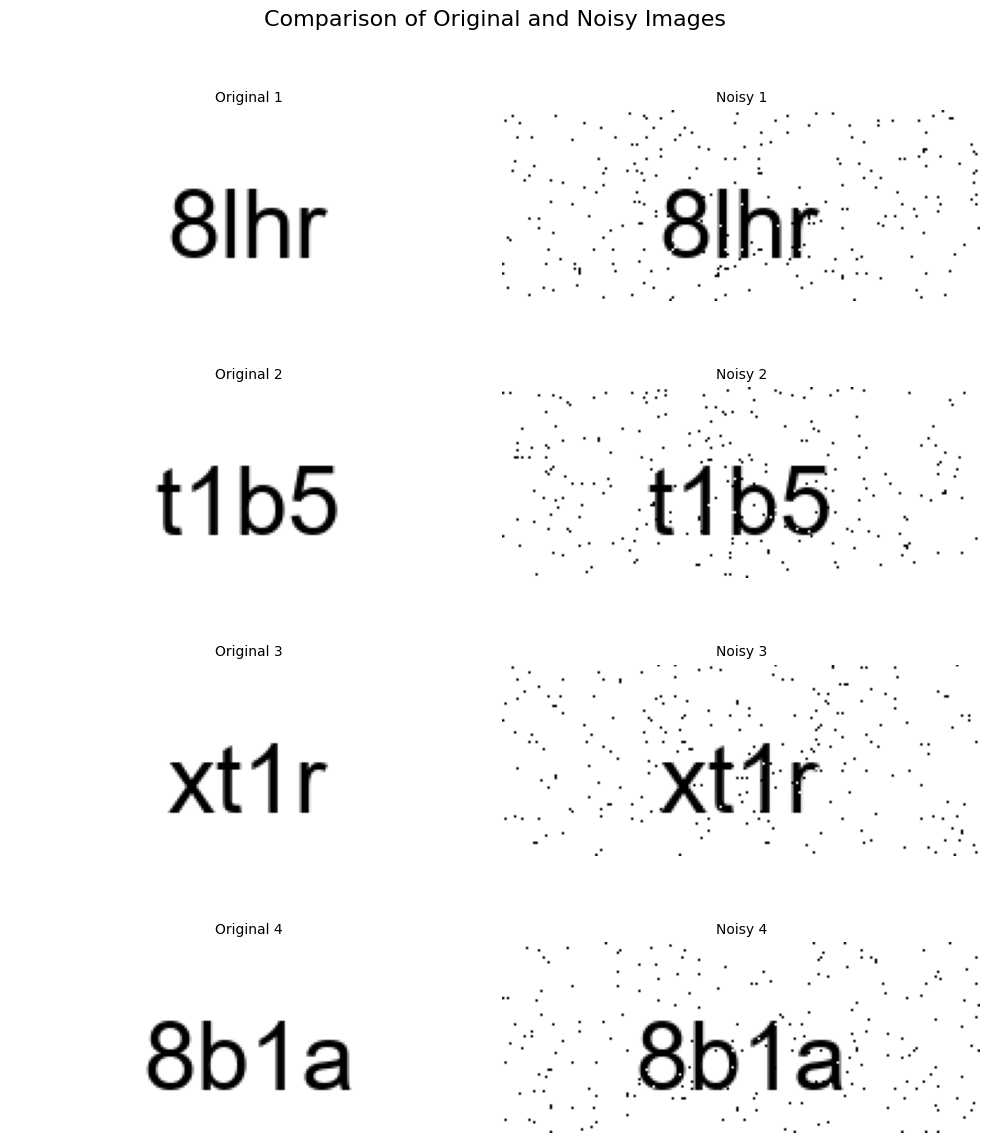

In [5]:
def add_salt_pepper_noise(image, salt_prob=0.03, pepper_prob=0.03):
    img_array = np.array(image)
    
    salt_mask = np.random.random(img_array.shape[:2]) < salt_prob/2
    img_array[salt_mask] = 255
    
    pepper_mask = np.random.random(img_array.shape[:2]) < pepper_prob/2
    img_array[pepper_mask] = 0
    
    return Image.fromarray(img_array)

for i in range(1, 21):
    filename = f"captcha_{captcha_data[i-1]['text']}.png"
    
    original_path = os.path.join(GENERATED_CAPTCHAS_DIR, filename)
    image = Image.open(original_path)
    
    noisy_image = add_salt_pepper_noise(image, salt_prob=0.03, pepper_prob=0.03)
    
    noisy_path = os.path.join(NOISY_CAPTCHAS_DIR, filename)
    noisy_image.save(noisy_path)
    
print(f"Noise was added to all images")

print(f"\nAll noisy images were saved in {NOISY_CAPTCHAS_DIR}")

fig, axes = plt.subplots(4, 2, figsize=(10, 12))
fig.suptitle('Comparison of Original and Noisy Images', fontsize=16, y=0.995)

for idx in range(4):
    filename = f"captcha_{captcha_data[idx]['text']}.png"
    
    original = Image.open(os.path.join(GENERATED_CAPTCHAS_DIR, filename))
    noisy = Image.open(os.path.join(NOISY_CAPTCHAS_DIR, filename))
    
    axes[idx, 0].imshow(original, cmap='gray')
    axes[idx, 0].set_title(f'Original {idx+1}', fontsize=10)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(noisy, cmap='gray')
    axes[idx, 1].set_title(f'Noisy {idx+1}', fontsize=10)
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

## Apply Gaussian Filter for Denoising

**Why Use Gaussian Filter?**

The Gaussian filter is chosen for noise reduction because:

1. **Weighted Averaging**: Instead of equally weighting all neighboring pixels, Gaussian filter uses a bell-shaped (Gaussian) distribution where closer pixels have higher weight. This creates a smooth, natural-looking blur.

2. **Effective Salt-and-Pepper Removal**: Salt-and-pepper noise appears as isolated bright (255) or dark (0) pixels. The Gaussian filter suppresses these outliers by averaging them with their neighbors, significantly reducing their impact.

3. **Preserves Edges Better**: Compared to uniform/box filters, Gaussian blur is gentler on edges and does not create harsh transitions, making it suitable for text-based images where character boundaries are important.

4. **Mathematically Elegant**: The Gaussian kernel is separable, allowing efficient computation and is consistent with how natural images degrade (blur), making it a natural choice for image restoration.

**Trade-offs**: 
- **Advantage**: Smooths noise and makes images more recognizable for machine learning
- **Disadvantage**: Slightly reduces image sharpness and can blur fine details like thin character strokes

**Implementation**: Uses OpenCV's `cv2.GaussianBlur()` with a 3×3 kernel, which provides a good balance between noise reduction and detail preservation.

Gaussian filter applied to all images
All filtered images were saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\filtered_captchas


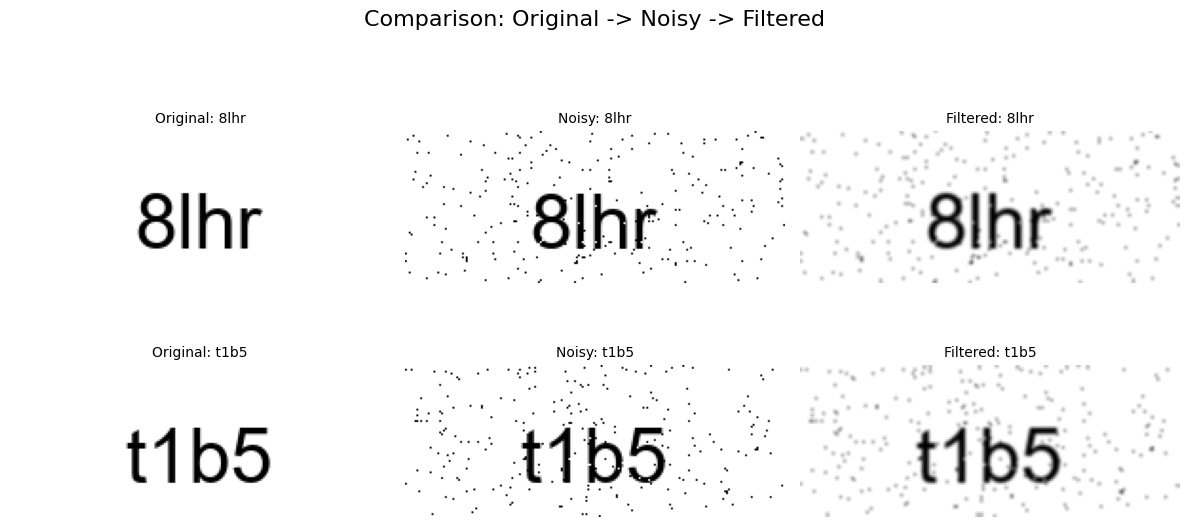

In [6]:
def apply_gaussian_filter(image, kernel_size=3, sigma=0):
    img_array = np.array(image)
    blurred = cv2.GaussianBlur(img_array, (kernel_size, kernel_size), sigma)
    return Image.fromarray(blurred)

for i in range(1, 21):
    filename = f"captcha_{captcha_data[i-1]['text']}.png"
    
    noisy_path = os.path.join(NOISY_CAPTCHAS_DIR, filename)
    noisy_image = Image.open(noisy_path)
    
    filtered_image = apply_gaussian_filter(noisy_image, kernel_size=3)
    
    filtered_path = os.path.join(FILTERED_CAPTCHAS_DIR, filename)
    filtered_image.save(filtered_path)

print("Gaussian filter applied to all images")
print(f"All filtered images were saved in {FILTERED_CAPTCHAS_DIR}")

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
fig.suptitle('Comparison: Original -> Noisy -> Filtered', fontsize=16, y=0.995)

for idx in range(2):
    filename = f"captcha_{captcha_data[idx]['text']}.png"
    text = df[df['filename'] == filename]['text'].values[0]
    
    original = Image.open(os.path.join(GENERATED_CAPTCHAS_DIR, filename))
    noisy = Image.open(os.path.join(NOISY_CAPTCHAS_DIR, filename))
    filtered = Image.open(os.path.join(FILTERED_CAPTCHAS_DIR, filename))
    
    axes[idx, 0].imshow(original, cmap='gray')
    axes[idx, 0].set_title(f'Original: {text}', fontsize=10)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(noisy, cmap='gray')
    axes[idx, 1].set_title(f'Noisy: {text}', fontsize=10)
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(filtered, cmap='gray')
    axes[idx, 2].set_title(f'Filtered: {text}', fontsize=10)
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()


# Part 2: Data Preprocessing

### Why Do Blur Filters Remove Noise?
Blur filters reduce noise because they replace each pixel value with a weighted average of its neighboring pixels.

Filters work by replacing each pixel with a weighted combination of its neighbors. The key principle is:
- **Noise is usually random and localized**: Noisy pixels often have values that are very different from surrounding pixels.
- **Natural images are spatially smooth**: Neighboring pixels in real images tend to have similar intensity values.
- **Averaging suppresses outliers**: When a pixel is averaged with its neighbors, extreme values caused by noise are reduced, while consistent image regions are preserved.

As a result, filters such as averaging and Gaussian filters smooth sudden intensity variations and therefore reduce noise. However, this smoothing process also removes some image details and edges, which causes the image to appear blurred.

Median filtering also reduces noise, but instead of averaging neighboring pixels, it replaces each pixel with the median value of its neighborhood. Since the median is less affected by extreme values, this method is especially effective for removing salt-and-pepper noise while preserving edges better than averaging filters.

### Median Filter vs Gaussian Filter (from Part 1)

| Aspect | Gaussian Filter | Median Filter |
|--------|-----------------|---------------|
| **Method** | Weighted average with Gaussian weights | Takes the middle value (median) |
| **Best for** | General smoothing, gradual noise | Salt-and-pepper noise |
| **Outlier handling** | Averages outliers (still affected) | Ignores outliers (completely removes them) |
| **Edge preservation** | Blurs edges | Preserves edges better |
| **Kernel size** | Larger = more blur | Larger = more aggressive removal |

**Why Median is Better for Salt-and-Pepper:**
- Salt (255) and pepper (0) are extreme outliers
- Median automatically rejects these outliers and uses realistic neighbor values
- Gaussian still includes these extreme values in the average, reducing their effect but not eliminating them
- Median is non-linear, making it superior for impulse noise while preserving edges

### Kernel Size Exploration
Different kernel sizes provide different trade-offs:
- **3×3**: Conservative filtering, preserves fine details but may leave some noise
- **5×5**: Balanced approach, removes more noise but may start blurring characters
- **7×7**: Aggressive filtering, removes most noise but can blur thin character strokes


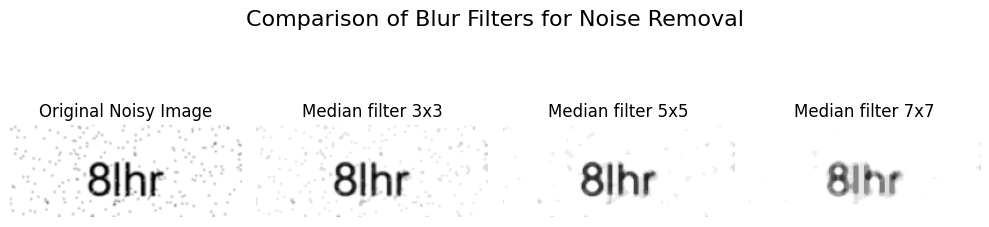

In [7]:
def apply_median_filter(image, kernel_size=3):
    img_array = np.array(image)
    denoised = cv2.medianBlur(img_array, kernel_size)
    return Image.fromarray(denoised)

sample_noisy = Image.open(os.path.join(FILTERED_CAPTCHAS_DIR, f"captcha_{captcha_data[0]['text']}.png"))

blur_3x3 = apply_median_filter(sample_noisy, kernel_size=3)
blur_5x5 = apply_median_filter(sample_noisy, kernel_size=5)
blur_7x7 = apply_median_filter(sample_noisy, kernel_size=7)

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
fig.suptitle('Comparison of Blur Filters for Noise Removal', fontsize=16)

axes[0].imshow(sample_noisy, cmap='gray')
axes[0].set_title('Original Noisy Image')
axes[0].axis('off')

axes[1].imshow(blur_3x3, cmap='gray')
axes[1].set_title('Median filter 3x3')
axes[1].axis('off')

axes[2].imshow(blur_5x5, cmap='gray')
axes[2].set_title('Median filter 5x5')
axes[2].axis('off')

axes[3].imshow(blur_7x7, cmap='gray')
axes[3].set_title('Median filter 7x7')
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [8]:
print("\nApplying Median filter 3*3 to all filtered images...")

for i in range(1, 21):
    filename = f"captcha_{captcha_data[i-1]['text']}.png"
    noisy_img = Image.open(os.path.join(FILTERED_CAPTCHAS_DIR, filename))
    denoised = apply_median_filter(noisy_img, kernel_size=3)
    denoised.save(os.path.join(DENOISED_CAPTCHAS_DIR, filename))

print(f"Filtered images saved in {DENOISED_CAPTCHAS_DIR}")


Applying Median filter 3*3 to all filtered images...
Filtered images saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\denoised_captchas


### Sharpening vs De-blurring: Research and Justification

**Sharpening:**
- **How it works**: Enhances edges by amplifying differences between adjacent pixels
- **Use case**: Restores lost detail and makes edges crisp and clear
- **Kernel example**: [[0, -1, 0], [-1, 5, -1], [0, -1, 0]]
  - Center: 5 (high weight on current pixel)
  - Neighbors: -1 (subtracts neighbor values)
  - Effect: Emphasizes deviations from neighbors, creating edge enhancement

**De-blurring (Deconvolution):**
- **How it works**: Attempts to reverse the blur by estimating and inverting the blur kernel
- **Use case**: Recovery when you know what blur operation was applied
- **Challenge**: Requires knowledge of blur kernel; amplifies noise; computationally intensive

### Why We Choose Sharpening?

1. **Robustness**: Works without knowing the blur kernel
2. **Computational efficiency**: Simple convolution vs complex deconvolution
3. **Noise handling**: Direct sharpening is less prone to amplifying noise than de-blurring
4. **CAPTCHA context**: Our images have already been smoothed by the median filter, making sharpening ideal to restore text edges
5. **Practical results**: Enhances character boundaries for better recognition

### The Sharpening Kernel

```
Kernel = [  0  -1   0 ]
         [ -1   5  -1 ]
         [  0  -1   0 ]
```

This is called an **unsharp mask**:
- **Central 5**: Multiplies the current pixel by 5
- **-1 neighbors**: Subtracts the influence of surrounding pixels
- **Net effect**: 5×original - (sum of 4 neighbors) = 5×original - 4×average ≈ original + 4×(original - average)
- **Result**: The pixel is pushed away from the average of its neighbors, creating emphasized edges

In [9]:
def apply_sharpen_filter(image):
    img_array = np.array(image)

    kernel_sharpen = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])

    sharpened = cv2.filter2D(img_array, -1, kernel_sharpen)

    return Image.fromarray(sharpened)

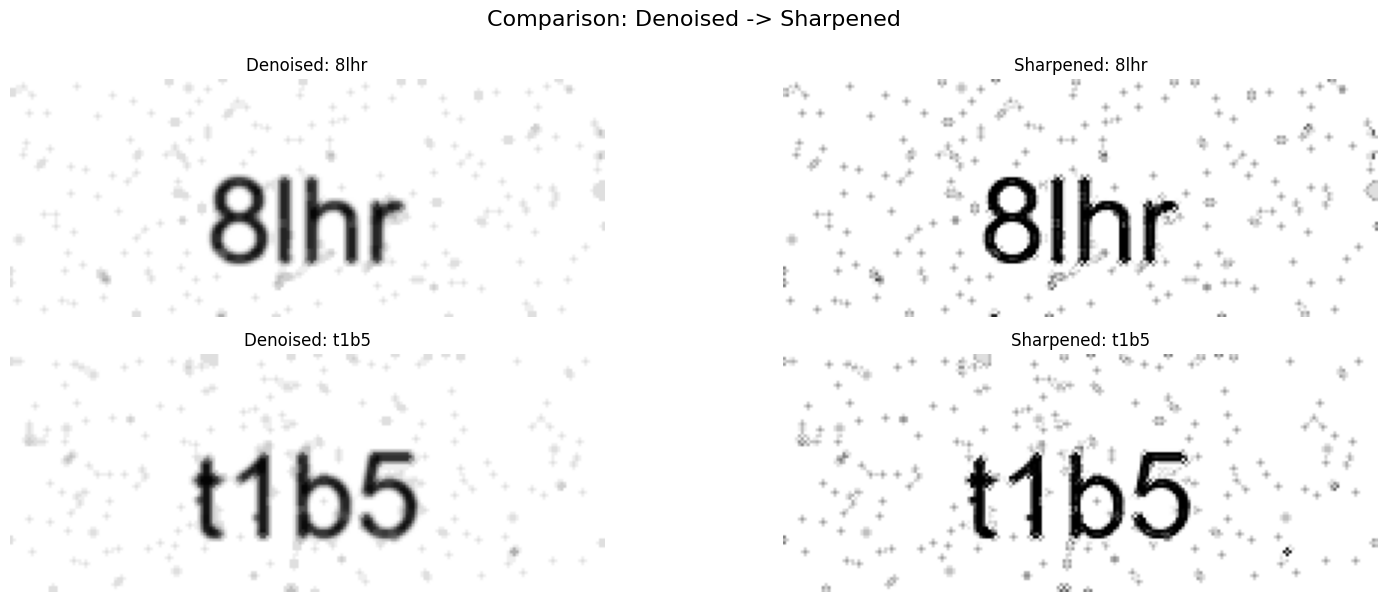


Applying sharpening filter to all images...
Sharpened images saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\sharpened_captchas


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 6))
fig.suptitle('Comparison: Denoised -> Sharpened', fontsize=16, y=0.995)

for idx in range(2):
    filename = f"captcha_{captcha_data[idx]['text']}.png"
    sample_img = Image.open(os.path.join(DENOISED_CAPTCHAS_DIR, filename))
    
    sharpened = apply_sharpen_filter(sample_img)
    
    axes[idx, 0].imshow(sample_img, cmap='gray')
    axes[idx, 0].set_title(f"Denoised: {captcha_data[idx]['text']}")
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(sharpened, cmap='gray')
    axes[idx, 1].set_title(f"Sharpened: {captcha_data[idx]['text']}")
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

print("\nApplying sharpening filter to all images...")
sharpened_dir = os.path.join(DATA_DIR, 'sharpened_captchas')
os.makedirs(sharpened_dir, exist_ok=True)

for i in range(1, 21):
    filename = f"captcha_{captcha_data[i-1]['text']}.png"
    denoised_img = Image.open(os.path.join(DENOISED_CAPTCHAS_DIR, filename))
    sharpened = apply_sharpen_filter(denoised_img)
    
    sharpened.save(os.path.join(SHARPENED_CAPTCHAS_DIR, filename))

print(f"Sharpened images saved in {SHARPENED_CAPTCHAS_DIR}")


### What is Binarization?

Binarization converts a grayscale image into a binary image (only 0 and 255 values):
- **Black (0)**: Background
- **White (255)**: Foreground (text/objects)

This simplifies the image to its most essential information, ideal for document/text recognition.

### Otsu's Threshold Method

Instead of manually choosing a threshold value, **Otsu's method** automatically finds the optimal threshold by:

1. Computing the histogram of pixel values
2. Calculating class variance for all possible thresholds
3. Selecting the threshold that maximizes variance between background and foreground
4. Result: Automatic, optimal separation without trial-and-error

**Advantages:**
- No manual tuning needed
- Adaptive to different lighting conditions
- Mathematically optimal for bimodal distributions (two peaks: background + foreground)

### Connected Component Analysis (CCA)

After binarization, we use **CCA to identify and remove noise**:

**Process:**
1. Label all connected white pixels as separate components (components = connected groups of foreground pixels)
2. Calculate the area (number of pixels) for each component
3. Remove components smaller than a threshold (these are noise/artifacts)
4. Keep only components larger than the threshold (these are real text)

### Threshold Value: Fixed or Adaptive?

**What does the threshold mean?**
- It's the **minimum area (in pixels)** a connected component must have to be considered "real" content
- In our code: `min_size_threshold = 40` means any blob with fewer than 40 pixels is removed as noise

**Is it fixed or adaptive?**
- **Currently: Fixed** (40 pixels) - works well when image resolution is consistent
- **Could be adaptive**: Calculate threshold based on image statistics
  - E.g.: `threshold = image_height × 0.05` (5% of image height)
  - E.g.: `threshold = (image_area / expected_num_chars) × 0.1`

**Factors affecting optimal threshold:**
- Image resolution (larger images need larger thresholds)
- Expected number of characters (fewer chars = larger per-char area)
- Character size and style
- Amount of remaining noise after filtering

For fixed-size CAPTCHA images (200×80), a fixed threshold of 40 pixels is appropriate because each character should occupy roughly 1600+ pixels.

In [11]:
def binarize_and_clean(image):
    min_size_threshold = 40
    
    gray = image.convert("L")
    img_array = np.array(gray)
    
    _, binary = cv2.threshold(img_array, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)    
    
    cleaned = np.zeros_like(binary)
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_size_threshold:
            cleaned[labels == i] = 255
    
    return Image.fromarray(cleaned)

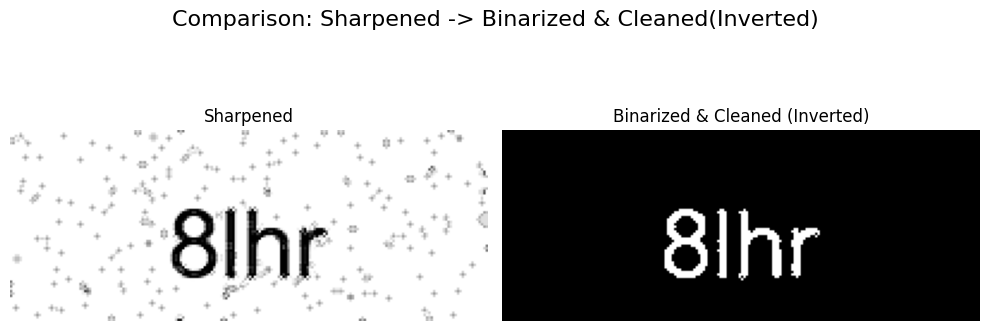


Applying binarization and cleaning to all images...
Binarized and cleaned images saved in e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\binarized_captchas


In [12]:
sample_sharp = Image.open(os.path.join(SHARPENED_CAPTCHAS_DIR, f"captcha_{captcha_data[0]['text']}.png"))
bin_sample = binarize_and_clean(sample_sharp)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Comparison: Sharpened -> Binarized & Cleaned(Inverted)', fontsize=16, y=0.995)
axes[0].imshow(sample_sharp, cmap='gray')
axes[0].set_title("Sharpened")
axes[0].axis('off')

axes[1].imshow(bin_sample, cmap='gray')
axes[1].set_title("Binarized & Cleaned (Inverted)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\nApplying binarization and cleaning to all images...")
cleaned_dir = os.path.join(DATA_DIR, 'binarized_captchas')
os.makedirs(cleaned_dir, exist_ok=True)

for i in range(1, 21):
    filename = f"captcha_{captcha_data[i-1]['text']}.png"
    sharp_img = Image.open(os.path.join(SHARPENED_CAPTCHAS_DIR, filename))
    cleaned = binarize_and_clean(sharp_img)
    
    cleaned.save(os.path.join(BINARIZED_CAPTCHAS_DIR, filename))

print(f"Binarized and cleaned images saved in {BINARIZED_CAPTCHAS_DIR}")

## Comparison

The preprocessing pipeline transforms noisy, low-quality images into clean, binary representations suitable for machine learning:

### Complete Pipeline Stages:

1. **Original**: Generated CAPTCHA images
2. **Noisy**: Salt-and-pepper noise added
3. **Filtered (Gaussian)**: Initial noise reduction
4. **Denoised (Median)**: Superior noise removal using median filter
   - Better than Gaussian for salt-and-pepper noise
   - Preserves edges while removing outliers
5. **Sharpened**: Edge enhancement using unsharp mask kernel
   - Restores clarity lost during smoothing
   - Uses convolution: 5×center - 4×neighbors
6. **Cleaned (Binary)**: Final binarization and noise removal
   - Otsu's automatic threshold finds optimal separation
   - Connected component analysis removes artifacts < 40 pixels
   - Result: Clean binary image ready for segmentation

Creating overall comparison image of preprocessing stages


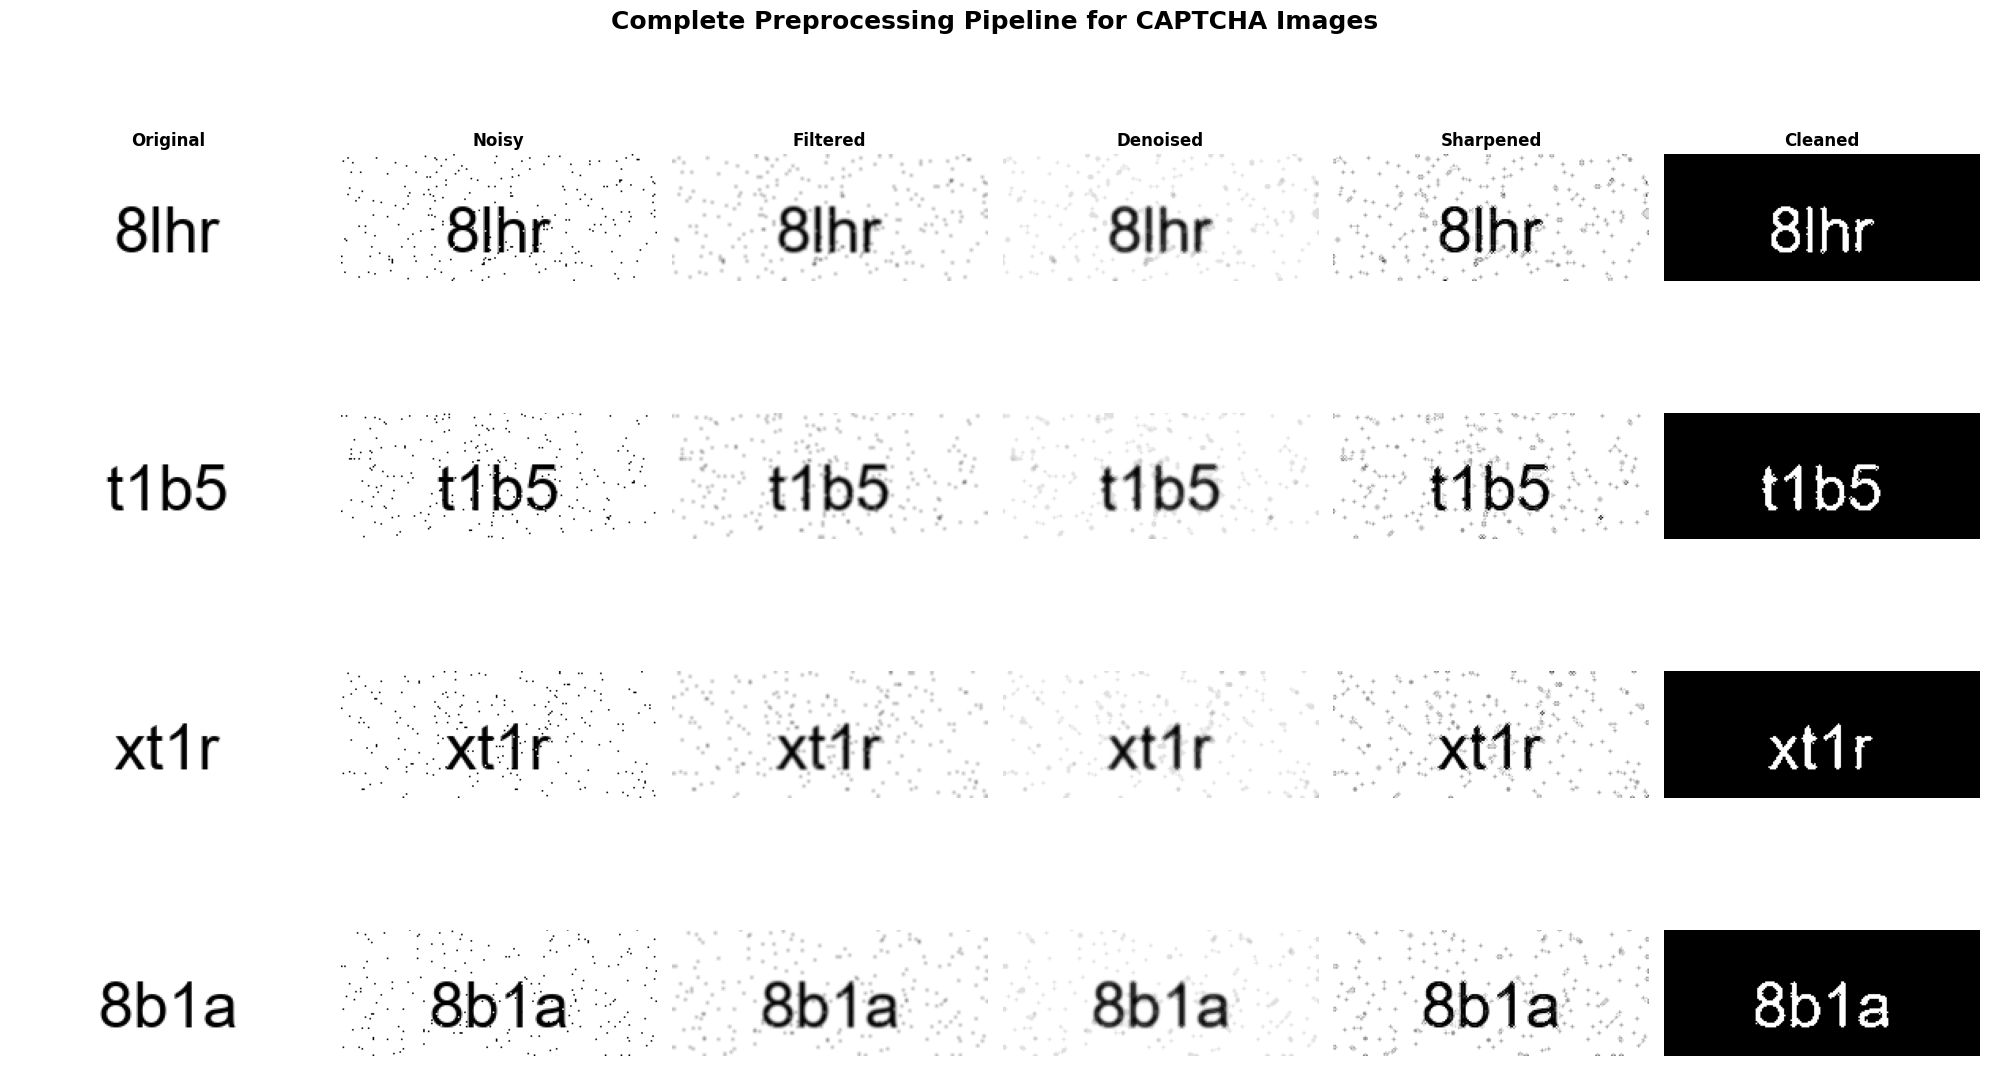

In [13]:
print("Creating overall comparison image of preprocessing stages")

fig = plt.figure(figsize=(20, 12))

for idx in range(4):
    filename = f"captcha_{captcha_data[idx]['text']}.png"
    
    original = Image.open(os.path.join(GENERATED_CAPTCHAS_DIR, filename))
    noisy = Image.open(os.path.join(NOISY_CAPTCHAS_DIR, filename))
    filtered = Image.open(os.path.join(FILTERED_CAPTCHAS_DIR, filename))
    denoised = Image.open(os.path.join(DENOISED_CAPTCHAS_DIR, filename))
    sharpened = Image.open(os.path.join(SHARPENED_CAPTCHAS_DIR, filename))
    cleaned = Image.open(os.path.join(BINARIZED_CAPTCHAS_DIR, filename))
    
    row = idx
    
    ax1 = fig.add_subplot(4, 6, row*6 + 1)
    ax1.imshow(original, cmap='gray')
    if idx == 0:
        ax1.set_title('Original', fontsize=12, fontweight='bold')
    ax1.set_ylabel(f'Sample {idx+1}', fontsize=11)
    ax1.axis('off')
    
    ax2 = fig.add_subplot(4, 6, row*6 + 2)
    ax2.imshow(noisy, cmap='gray')
    if idx == 0:
        ax2.set_title('Noisy', fontsize=12, fontweight='bold')
    ax2.axis('off')
    
    ax3 = fig.add_subplot(4, 6, row*6 + 3)
    ax3.imshow(filtered, cmap='gray')
    if idx == 0:
        ax3.set_title('Filtered', fontsize=12, fontweight='bold')
    ax3.axis('off')
    
    ax4 = fig.add_subplot(4, 6, row*6 + 4)
    ax4.imshow(denoised, cmap='gray')
    if idx == 0:
        ax4.set_title('Denoised', fontsize=12, fontweight='bold')
    ax4.axis('off')
    
    ax5 = fig.add_subplot(4, 6, row*6 + 5)
    ax5.imshow(sharpened, cmap='gray')
    if idx == 0:
        ax5.set_title('Sharpened', fontsize=12, fontweight='bold')
    ax5.axis('off')

    ax6 = fig.add_subplot(4, 6, row*6 + 6)
    ax6.imshow(cleaned, cmap='gray')
    if idx == 0:
        ax6.set_title('Cleaned', fontsize=12, fontweight='bold')
    ax6.axis('off')

fig.suptitle('Complete Preprocessing Pipeline for CAPTCHA Images', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Part 3: Segmentation

This section extracts individual characters from the cleaned binary CAPTCHA images produced in Part 2.

- We use connected component analysis on the cleaned binary image
- Each connected white region should correspond to one character
- Extracted regions are sorted from left to right by their x-coordinate
- Each character is resized to **64×64 pixels** so the output images match the Mapset image size

The code prints the number of extracted character images for each CAPTCHA.

In [14]:
for idx in range(len(captcha_data)):
    filename = f"captcha_{captcha_data[idx]['text']}.png"
    base_name = os.path.splitext(filename)[0]
    print(base_name)

captcha_8lhr
captcha_t1b5
captcha_xt1r
captcha_8b1a
captcha_1w3w
captcha_nc03
captcha_kqif
captcha_t4re
captcha_x1wc
captcha_8bro
captcha_c2vp
captcha_qkdk
captcha_4n4b
captcha_n96g
captcha_sci9
captcha_inmc
captcha_0kok
captcha_o4k6
captcha_1nvx
captcha_0j6i


In [15]:
for idx in range(len(captcha_data)):
    filename = f"captcha_{captcha_data[idx]['text']}.png"
    base_name = os.path.splitext(filename)[0]
    path = os.path.join(BINARIZED_CAPTCHAS_DIR, filename)
    
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(img, connectivity=8)
    
    char_images = []
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        char_img = img[y:y+h, x:x+w]
        char_images.append((x, char_img))

    char_images = sorted(char_images, key=lambda item: item[0])

    for i, (x, char_img) in enumerate(char_images):
        resized = cv2.resize(char_img, (64, 64))
        out_path = os.path.join(SEGMENTED_CHARS_DIR, f"{base_name}_char{i}.png")
        cv2.imwrite(out_path, resized)

    print(f"{filename}: {len(char_images)} characters extracted")

captcha_8lhr.png: 4 characters extracted
captcha_t1b5.png: 4 characters extracted
captcha_xt1r.png: 4 characters extracted
captcha_8b1a.png: 4 characters extracted
captcha_1w3w.png: 4 characters extracted
captcha_nc03.png: 4 characters extracted
captcha_kqif.png: 4 characters extracted
captcha_t4re.png: 4 characters extracted
captcha_x1wc.png: 4 characters extracted
captcha_8bro.png: 4 characters extracted
captcha_c2vp.png: 4 characters extracted
captcha_qkdk.png: 4 characters extracted
captcha_4n4b.png: 4 characters extracted
captcha_n96g.png: 4 characters extracted
captcha_sci9.png: 4 characters extracted
captcha_inmc.png: 4 characters extracted
captcha_0kok.png: 4 characters extracted
captcha_o4k6.png: 4 characters extracted
captcha_1nvx.png: 4 characters extracted
captcha_0j6i.png: 4 characters extracted


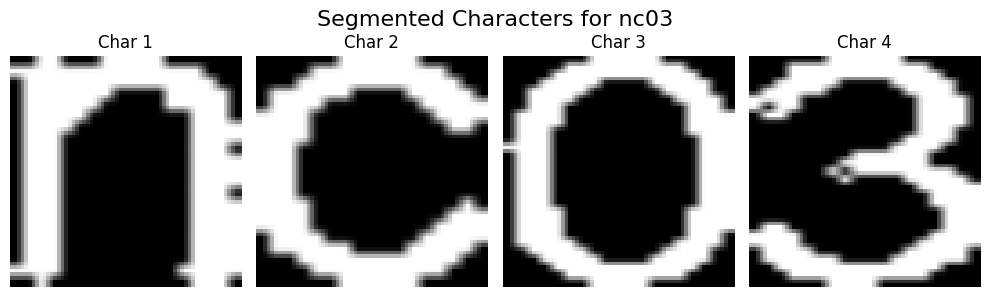

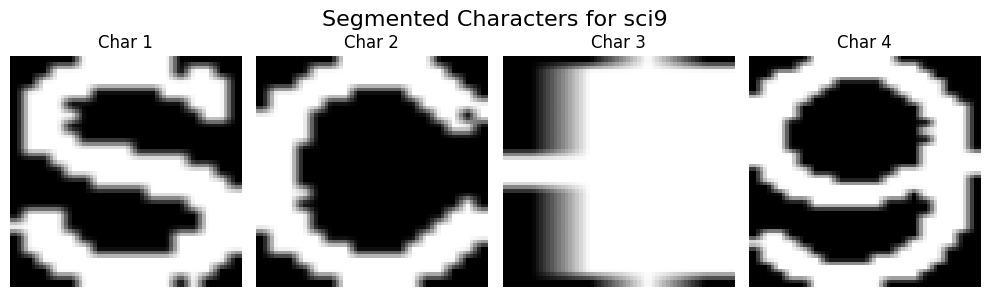

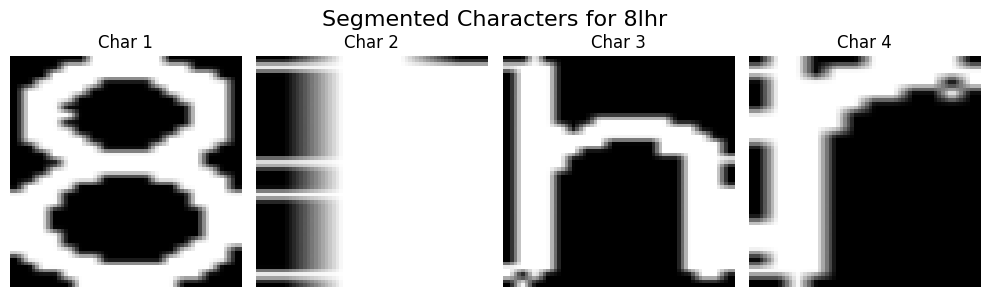

In [16]:
def show_segmented_characters(captcha_index=0, max_chars=10):
    filename = f"captcha_{captcha_data[captcha_index]['text']}.png"
    base_name = os.path.splitext(filename)[0]

    segment_files = sorted(
        [f for f in os.listdir(SEGMENTED_CHARS_DIR) if f.startswith(base_name)],
        key=lambda name: int(name.split('_char')[-1].split('.png')[0])
    )

    segment_files = segment_files[:max_chars]
    n = len(segment_files)

    fig, axes = plt.subplots(1, n, figsize=(n * 2.5, 3))
    fig.suptitle(f"Segmented Characters for {captcha_data[captcha_index]['text']}", fontsize=16)

    if n == 1:
        axes = [axes]

    for i, seg_file in enumerate(segment_files):
        img = Image.open(os.path.join(SEGMENTED_CHARS_DIR, seg_file))
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Char {i+1}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

show_segmented_characters(captcha_index=np.random.randint(0, len(captcha_data)))
show_segmented_characters(captcha_index=np.random.randint(0, len(captcha_data)))
show_segmented_characters(captcha_index=np.random.randint(0, len(captcha_data)))

# Part 4: Character Recognition

## Similarity Algorithms & Recognition

In this section, every segmented captcha character is compared against every template image in the Mapset directory. The objective is to identify the most similar template and predict the corresponding character label.

To evaluate the effectiveness of different non-learning-based recognition approaches, some similarity methods which are Pixel-Based, were implemented and compared.

---

## Recognition Pipeline

For each segmented character:

1. The segmented image is loaded.
2. Every template image from the Mapset is compared against it.
3. A similarity score is computed using each method.
4. The template with the best score is selected as the prediction.
5. The predicted label is compared against the ground-truth label.
6. Accuracy is calculated for each method independently.

---

### Template Matching

```python
cv2.matchTemplate(..., cv2.TM_CCOEFF_NORMED)
```

#### Description

Template Matching is a classical pixel-based comparison technique. The method slides one image over another and computes the normalized cross-correlation between them.

Since all segmented characters and templates are resized to identical dimensions, the algorithm produces a single similarity score.

This method measures how strongly the intensity patterns of two images correlate spatially.

---

#### Metric

- Range: `[-1.0 , 1.0]`
- Higher score indicates better similarity.

| Score | Meaning |
|---|---|
| 1.0 | Perfect match |
| 0.0 | No correlation |
| -1.0 | Opposite correlation |

---

#### Advantages

- Very fast
- Simple implementation
- Effective when characters are aligned

---

#### Limitations

- Sensitive to:
  - small shifts
  - noise
  - scaling
  - distortions

---

### Structural Similarity Index (SSIM)

```python
skimage.metrics.structural_similarity
```

#### Description

SSIM is a perceptual image similarity metric designed to model how humans visually compare images.

Instead of comparing pixels independently, SSIM evaluates three properties:

1. Luminance
2. Contrast
3. Structural similarity

This makes SSIM significantly more robust than direct pixel subtraction methods such as MSE.

---

#### Metric

- Range: `[0.0 , 1.0]`
- Higher score indicates greater similarity.

| Score | Meaning |
|---|---|
| 1.0 | Identical images |
| 0.0 | Completely different |

---

#### Advantages

- More robust than MSE
- Better perceptual comparison
- Preserves structural information

---

#### Limitations

- Still sensitive to large misalignment
- Computationally heavier than correlation

---

### Pearson Correlation

```python
np.corrcoef()
```

#### Description

In this method, both images are flattened into one-dimensional vectors. The Pearson Correlation Coefficient is then calculated between the two vectors.

The method measures how strongly pixel intensities vary together.

If bright and dark regions appear in similar locations in both images, the correlation score becomes high.

---

#### Metric

- Range: `[-1.0 , 1.0]`
- Higher score indicates stronger similarity.

| Score | Meaning |
|---|---|
| 1.0 | Perfect positive correlation |
| 0.0 | No relationship |
| -1.0 | Perfect negative correlation |

---

#### Advantages

- Very simple
- Computationally efficient
- Effective for aligned binary images

---

#### Limitations

- Extremely sensitive to:
  - translation
  - scaling
  - noise
  - thickness changes

---

### Mean Squared Error (MSE)

```python
np.mean((img1 - img2) ** 2)
```

#### Description

MSE computes the average squared difference between corresponding pixels in two images.

It is one of the simplest image similarity metrics.

If two images are identical, the error becomes zero.

Larger pixel differences produce larger error values.

---

#### Metric

- Range: `[0.0 , +∞)`
- Lower score indicates greater similarity.

| Score | Meaning |
|---|---|
| 0.0 | Perfect match |
| Large value | Large difference |

---

#### Advantages

- Very fast
- Easy to implement
- Useful baseline metric

---

#### Limitations

- Extremely sensitive to:
  - noise
  - translation
  - scaling
  - rotation

- Does not model perceptual similarity

---

## Accuracy Evaluation

For each method:

1. The predicted label was compared with the ground-truth character.
2. The number of correct predictions was counted.
3. Accuracy was computed using:

```python
accuracy = (correct_predictions / total_samples) * 100
```

The method with the highest recognition accuracy was selected as the best-performing approach.


In [17]:
mapset_images = []

for f in sorted(os.listdir(MAPSET_DIR)):
    file_path = os.path.join(MAPSET_DIR, f)

    if not os.path.isfile(file_path):
        continue

    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

    if img is None or np.std(img) < 1.0:
        continue

    mapset_images.append({
        "name": f,
        "image": img
    })

segmented_paths = sorted(glob.glob(os.path.join(SEGMENTED_CHARS_DIR, "*.png")))

all_results = []

for s_path in segmented_paths:
    char_img_wb = cv2.imread(s_path, cv2.IMREAD_GRAYSCALE)
    filename = os.path.basename(s_path)

    base_name = filename.split('_')[1]
    char_idx = int(
        filename.split('_')[2].split('.')[0][-1]
    )
    ground_truth_char = base_name[char_idx]
    char_flat = char_img_wb.flatten()

    best_template_score = -1.0
    best_template_label = None

    best_ssim_score = -1.0
    best_ssim_label = None

    best_corr_score = -1.0
    best_corr_label = None

    best_mse_score = float("inf")
    best_mse_label = None

    for ref in mapset_images:
        ref_img_wb = ref["image"]
        ref_label = ref["name"].split('.')[0]

        if ref_img_wb.shape != char_img_wb.shape:
            ref_img_resized = cv2.resize(
                ref_img_wb,
                (char_img_wb.shape[1], char_img_wb.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )
        else:
            ref_img_resized = ref_img_wb

        ref_flat = ref_img_resized.flatten()

        # TEMPLATE MATCHING
        template_score = cv2.matchTemplate(
            char_img_wb,
            ref_img_resized,
            cv2.TM_CCOEFF_NORMED
        )[0][0]

        if template_score > best_template_score:
            best_template_score = template_score
            best_template_label = ref_label

        # SSIM
        ssim_score = ssim(
            char_img_wb,
            ref_img_resized,
            data_range=255
        )

        if ssim_score > best_ssim_score:
            best_ssim_score = ssim_score
            best_ssim_label = ref_label

        # PEARSON CORRELATION
        std_char = np.std(char_flat)
        std_ref = np.std(ref_flat)

        if std_char == 0 or std_ref == 0:
            corr_score = 0.0

        else:
            corr_score = np.corrcoef(
                char_flat,
                ref_flat
            )[0, 1]

            if np.isnan(corr_score):
                corr_score = 0.0

        if corr_score > best_corr_score:
            best_corr_score = corr_score
            best_corr_label = ref_label

        # MSE
        mse_score = np.mean(
            (char_img_wb.astype("float") -
             ref_img_resized.astype("float")) ** 2
        )

        if mse_score < best_mse_score:
            best_mse_score = mse_score
            best_mse_label = ref_label

        
    all_results.append({

        "Image": filename,
        "Ground_Truth": ground_truth_char,

        "Template_Prediction": best_template_label,
        "Template_Score": best_template_score,

        "SSIM_Prediction": best_ssim_label,
        "SSIM_Score": best_ssim_score,

        "Corr_Prediction": best_corr_label,
        "Corr_Score": best_corr_score,

        "MSE_Prediction": best_mse_label,
        "MSE_Score": best_mse_score,
    })

In [18]:
df = pd.DataFrame(all_results)

methods = [
    "Template",
    "SSIM",
    "Corr",
    "MSE"
]

best_method = None
best_acc = -1

print("\n--- Final Accuracy Report ---")

for m in methods:
    correct = sum(df[f"{m}_Prediction"] == df["Ground_Truth"])

    acc = (correct / len(df)) * 100

    print(f"{m}: {acc:.2f}%")

    if acc > best_acc:
        best_acc = acc
        best_method = m

print(
    f"\nBest Method: "
    f"{best_method} "
    f"with {best_acc:.2f}% accuracy."
)

final_df = df[[
    'Image',
    f'{best_method}_Prediction',
    f'{best_method}_Score'
]].copy()

final_df.columns = [
    'segment file',
    'predicted label',
    'Metric'
]

final_df.to_csv(CSV_RESULTS_PATH, index=False)

print(
    f"\nResults for {best_method} "
    f"successfully saved to {CSV_RESULTS_PATH}"
)


--- Final Accuracy Report ---
Template: 90.00%
SSIM: 77.50%
Corr: 90.00%
MSE: 87.50%

Best Method: Template with 90.00% accuracy.

Results for Template successfully saved to e:\University_Projects\Vision\Computer-Vision-Course\HW2\data\captcha\results.csv


In [19]:
print("\n--- Wrong Predictions ---")

wrong_count = 0

for _, row in df.iterrows():

    true_label = row["Ground_Truth"]
    predicted_label = row[best_method + "_Prediction"]

    if true_label != predicted_label:

        wrong_count += 1

        print(
            f"[{wrong_count}] "
            f"Image: {row['Image']} | "
            f"True: '{true_label}' | "
            f"Predicted: '{predicted_label}' | "
            f"Score: {row[best_method + '_Score']:.4f}"
        )
print("Total rows:", len(df))
print(f"\nTotal Wrong Predictions: {wrong_count}")


--- Wrong Predictions ---
[1] Image: captcha_0j6i_char3.png | True: 'i' | Predicted: 'f' | Score: 0.5337
[2] Image: captcha_8lhr_char1.png | True: 'l' | Predicted: 'j' | Score: 0.5850
[3] Image: captcha_c2vp_char0.png | True: 'c' | Predicted: 'o' | Score: 0.6331
[4] Image: captcha_inmc_char0.png | True: 'i' | Predicted: 'j' | Score: 0.5436
[5] Image: captcha_inmc_char3.png | True: 'c' | Predicted: 'o' | Score: 0.5826
[6] Image: captcha_kqif_char2.png | True: 'i' | Predicted: 't' | Score: 0.5439
[7] Image: captcha_n96g_char3.png | True: 'g' | Predicted: 'q' | Score: 0.5198
[8] Image: captcha_sci9_char2.png | True: 'i' | Predicted: 'j' | Score: 0.5142
Total rows: 80

Total Wrong Predictions: 8
